# Advanced Machine Learning Lab 10 — Federated Learning Part III: Privacy, Attacks, and Defenses

**Phase:** Spatial Adaptation → Privacy and Security  
**Duration:** 2 hours   
**Framework:** TensorFlow / Keras / NumPy / Matplotlib / scikit-learn  
**Constraint:** No federated learning library

## Learning objectives

By the end of this lab, you should be able to:

- simulate privacy attacks discussed in the lecture;
- implement simple defenses from scratch;
- compare attack success **with defense** and **without defense**;
- analyse the privacy–utility trade-off in federated learning;
- reason about why minority clients may pay a larger utility cost.

## Topics covered

1. Gradient inversion attack (DLG-style intuition)
2. Membership inference attack
3. DP-SGD from scratch (example-level DP)
4. Noisy FedAvg (client-level DP)
5. Privacy–utility–fairness analysis
6. Secure Aggregation (SecAgg) mask cancellation

## Pedagogical positioning

This lab follows the lecture on **"Why FL is not inherently private"** and operationalises the key ideas seen in class: model updates can leak information; privacy defenses are costly; and no single defense solves every threat.

In [24]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


## Part 0 — Dataset and Setup

We use the **scikit-learn digits** dataset (8×8 grayscale images, 10 classes). It is small enough to run quickly in class, yet rich enough to demonstrate both attacks and defenses.


In [25]:
# Load digits dataset

digits = load_digits()
X = digits.images.astype(np.float32) / 16.0
y = digits.target.astype(np.int32)

idx_all = np.arange(len(X))
train_idx, test_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

CLASSES = 10
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Classes:", np.unique(y_train))

Train: (1437, 8, 8, 1) Test: (360, 8, 8, 1)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [26]:
def make_tf_dataset(indices: np.ndarray, batch_size: int = 32, shuffle: bool = True):
    ds = tf.data.Dataset.from_tensor_slices((X_train[indices], y_train[indices]))
    if shuffle:
        ds = ds.shuffle(max(1, len(indices)), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def build_model(num_classes: int = 10) -> keras.Model:
    inp = keras.Input(shape=(8, 8, 1))
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPool2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPool2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out)


def compute_accuracy(model: keras.Model, xs: np.ndarray, ys: np.ndarray) -> float:
    probs = model(xs, training=False).numpy()
    preds = np.argmax(probs, axis=1)
    return float(np.mean(preds == ys))


def get_weights_copy(model: keras.Model) -> List[np.ndarray]:
    return [w.numpy().copy() for w in model.weights]


def set_weights_from(model: keras.Model, weights: List[np.ndarray]) -> None:
    for var, w in zip(model.weights, weights):
        var.assign(w)


def weighted_average(weight_lists: List[List[np.ndarray]], sample_counts: List[int]) -> List[np.ndarray]:
    total = sum(sample_counts)
    avg = [np.zeros_like(w) for w in weight_lists[0]]
    for wlist, n in zip(weight_lists, sample_counts):
        for i, w in enumerate(wlist):
            avg[i] += (n / total) * w
    return avg

## Part 1 — Non-IID Federated Partition

Before attacking the system, we need a federated setup. We simulate **K clients** with a Dirichlet partition to create label skew. Small Dirichlet concentration means stronger heterogeneity.

This matters because several lecture points depend on heterogeneity: noisy defenses may hurt minority clients more, and robust behavior in FL depends strongly on client distribution mismatch.

In [27]:
def dirichlet_partition(y_subset: np.ndarray,
                        indices: np.ndarray,
                        num_clients: int,
                        alpha: float,
                        seed: int = SEED) -> List[np.ndarray]:
    rng = np.random.default_rng(seed)
    num_classes = len(np.unique(y_subset))
    buckets = [[] for _ in range(num_clients)]

    for c in range(num_classes):
        class_idx = indices[y_subset == c]
        rng.shuffle(class_idx)
        proportions = rng.dirichlet(np.full(num_clients, alpha))
        cuts = (np.cumsum(proportions[:-1]) * len(class_idx)).astype(int)
        splits = np.split(class_idx, cuts)
        for k in range(num_clients):
            buckets[k].extend(splits[k].tolist())

    out = []
    for b in buckets:
        b = np.array(b, dtype=int)
        rng.shuffle(b)
        out.append(b)
    return out

K = 10
ALPHA = 0.3
client_indices = dirichlet_partition(y_train, np.arange(len(y_train)), K, ALPHA)
print("Client sizes:", [len(idx) for idx in client_indices])

Client sizes: [70, 154, 176, 228, 203, 30, 237, 185, 45, 109]


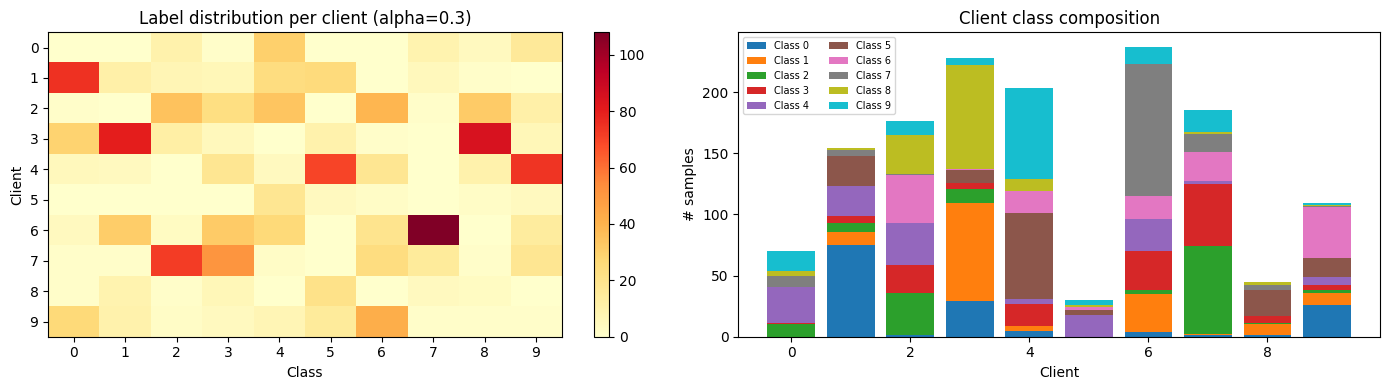

In [28]:
label_matrix = np.zeros((K, CLASSES), dtype=int)
for k, idx in enumerate(client_indices):
    label_matrix[k] = np.bincount(y_train[idx], minlength=CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
im = axes[0].imshow(label_matrix, aspect='auto', cmap='YlOrRd')
axes[0].set_title(f"Label distribution per client (alpha={ALPHA})")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Client")
axes[0].set_xticks(range(CLASSES))
axes[0].set_yticks(range(K))
plt.colorbar(im, ax=axes[0])

bottom = np.zeros(K)
colors = plt.cm.tab10(np.linspace(0, 1, CLASSES))
for c in range(CLASSES):
    axes[1].bar(range(K), label_matrix[:, c], bottom=bottom, color=colors[c], label=f"Class {c}")
    bottom += label_matrix[:, c]
axes[1].set_title("Client class composition")
axes[1].set_xlabel("Client")
axes[1].set_ylabel("# samples")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Part 2 — Reference Training Utilities

We now define a small centralised and federated baseline. These models will later be attacked.

The objective is not to build the best classifier, but to create a realistic training signal from which privacy leakage can be observed.

In [29]:
def train_central_model(train_idx: np.ndarray,
                        epochs: int = 10,
                        lr: float = 1e-3) -> keras.Model:
    model = build_model()
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    ds = make_tf_dataset(train_idx, batch_size=32, shuffle=True)
    model.fit(ds, epochs=epochs, verbose=0)
    return model


def client_update(global_weights: List[np.ndarray],
                  client_idx: int,
                  local_epochs: int,
                  lr: float,
                  cidx: List[np.ndarray]) -> List[np.ndarray]:
    local_model = build_model()
    set_weights_from(local_model, global_weights)
    local_model.compile(
        optimizer=keras.optimizers.SGD(lr),
        loss='sparse_categorical_crossentropy'
    )
    ds = make_tf_dataset(cidx[client_idx], batch_size=32, shuffle=True)
    local_model.fit(ds, epochs=local_epochs, verbose=0)
    return get_weights_copy(local_model)


def fedavg_aggregate(all_weights: List[List[np.ndarray]],
                     client_sizes: List[int]) -> List[np.ndarray]:
    return weighted_average(all_weights, client_sizes)


def run_fedavg(rounds: int = 20,
               local_epochs: int = 1,
               lr: float = 0.05,
               participation: float = 1.0,
               alpha: float = 0.3,
               seed: int = SEED,
               verbose: bool = True) -> Dict:
    rng = np.random.default_rng(seed)
    cidx = dirichlet_partition(y_train, np.arange(len(y_train)), K, alpha, seed=seed)
    global_model = build_model()
    global_weights = get_weights_copy(global_model)
    m = max(1, int(np.ceil(participation * K)))
    history = []

    for t in range(rounds):
        selected = rng.choice(K, size=m, replace=False)
        local_weights, sizes = [], []
        for k in selected:
            wk = client_update(global_weights, k, local_epochs, lr, cidx)
            local_weights.append(wk)
            sizes.append(len(cidx[k]))
        global_weights = fedavg_aggregate(local_weights, sizes)
        set_weights_from(global_model, global_weights)
        acc = compute_accuracy(global_model, X_test, y_test)
        history.append(acc)
        if verbose and (t == 0 or (t + 1) % 5 == 0):
            print(f"FedAvg round {t+1:02d}: acc={acc:.3f}")

    return {
        "history": history,
        "final_weights": global_weights,
        "client_indices": cidx,
        "global_model": global_model,
    }

In [30]:
ref_model = train_central_model(np.arange(len(y_train)), epochs=8)
print(f"Reference central accuracy: {compute_accuracy(ref_model, X_test, y_test):.3f}")

fedavg_result = run_fedavg(rounds=15, local_epochs=1, alpha=0.3, verbose=False)
print(f"Reference FedAvg accuracy: {fedavg_result['history'][-1]:.3f}")

Reference central accuracy: 0.953
Reference FedAvg accuracy: 0.539


## Part 3 — Gradient Inversion Attack (DLG-style)

### Theory

In the lecture, gradient inversion was introduced through **Deep Leakage from Gradients**: an attacker who sees a gradient can optimise a dummy input until it produces a matching gradient. If the match is good enough, the reconstructed input may visually resemble the private example.

This is an existence proof that **"data stays on device" is not a sufficient privacy guarantee**. In this lab, we implement a compact DLG-style attack on one digit image.

### Goal

- observe gradients from one private sample;
- reconstruct an approximate input from those gradients;
- compare reconstruction **without defense** and **with a simple gradient defense**.

In [31]:
def get_true_gradient(model: keras.Model,
                      x_private: np.ndarray,
                      y_private: int) -> List[tf.Tensor]:
    loss_fn = keras.losses.SparseCategoricalCrossentropy()
    y_tf = tf.constant([y_private], dtype=tf.int32)
    with tf.GradientTape() as tape:
        preds = model(x_private, training=False)
        loss = loss_fn(y_tf, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    return [tf.identity(g) for g in grads]


def apply_gradient_defense(grads: List[tf.Tensor], mode: str = 'none', param: float = 0.1) -> List[tf.Tensor]:
    defended = []
    for g in grads:
        arr = g.numpy().copy()
        if mode == 'none':
            pass
        elif mode == 'noise':
            arr = arr + np.random.normal(0.0, param, size=arr.shape)
        elif mode == 'compress':
            thr = np.quantile(np.abs(arr).ravel(), param)
            arr[np.abs(arr) < thr] = 0.0
        else:
            raise ValueError("Unknown defense mode")
        defended.append(tf.convert_to_tensor(arr, dtype=tf.float32))
    return defended


def gradient_inversion_attack(model: keras.Model,
                              true_grads: List[tf.Tensor],
                              n_iter: int = 300,
                              lr_attack: float = 0.05,
                              num_classes: int = 10) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    x_dummy   = tf.Variable(tf.random.normal((1, 8, 8, 1), seed=0), dtype=tf.float32)
    y_logits  = tf.Variable(tf.random.normal((1, num_classes), seed=1), dtype=tf.float32)
    optimizer = keras.optimizers.Adam(lr_attack)

    # Pre-cast true gradients as constants so they are embedded in the compiled graph
    true_grads_const = [tf.constant(g.numpy(), dtype=tf.float32) for g in true_grads]

    @tf.function
    def attack_step():
        with tf.GradientTape() as outer_tape:
            with tf.GradientTape() as inner_tape:
                preds  = model(x_dummy, training=False)
                y_soft = tf.nn.softmax(y_logits)
                loss   = tf.reduce_mean(
                    tf.keras.losses.categorical_crossentropy(y_soft, preds))
            dummy_grads = inner_tape.gradient(loss, model.trainable_variables)
            match_loss  = tf.add_n([
                tf.reduce_sum(tf.square(dg - tg))
                for dg, tg in zip(dummy_grads, true_grads_const)
            ])
        grads_vars = outer_tape.gradient(match_loss, [x_dummy, y_logits])
        optimizer.apply_gradients(zip(grads_vars, [x_dummy, y_logits]))
        x_dummy.assign(tf.clip_by_value(x_dummy, 0.0, 1.0))
        return match_loss

    loss_history = []
    for _ in range(n_iter):
        ml = attack_step()
        loss_history.append(float(ml.numpy()))

    return x_dummy.numpy(), tf.nn.softmax(y_logits).numpy(), loss_history


In [32]:
# Attack one private sample
private_idx = 42
x_private = X_train[private_idx:private_idx+1]
y_private = int(y_train[private_idx])

true_grads = get_true_gradient(ref_model, x_private, y_private)
recon_x, recon_y, dlg_loss = gradient_inversion_attack(ref_model, true_grads, n_iter=400, lr_attack=0.05)

# Defended version: add Gaussian noise to shared gradients
true_grads_noisy = apply_gradient_defense(true_grads, mode='noise', param=0.05)
recon_x_noisy, recon_y_noisy, dlg_loss_noisy = gradient_inversion_attack(ref_model, true_grads_noisy, n_iter=400, lr_attack=0.05)

print("True label:", y_private)
print("Recovered label without defense:", int(np.argmax(recon_y)))
print("Recovered label with noisy gradients:", int(np.argmax(recon_y_noisy)))

True label: 8
Recovered label without defense: 2
Recovered label with noisy gradients: 4


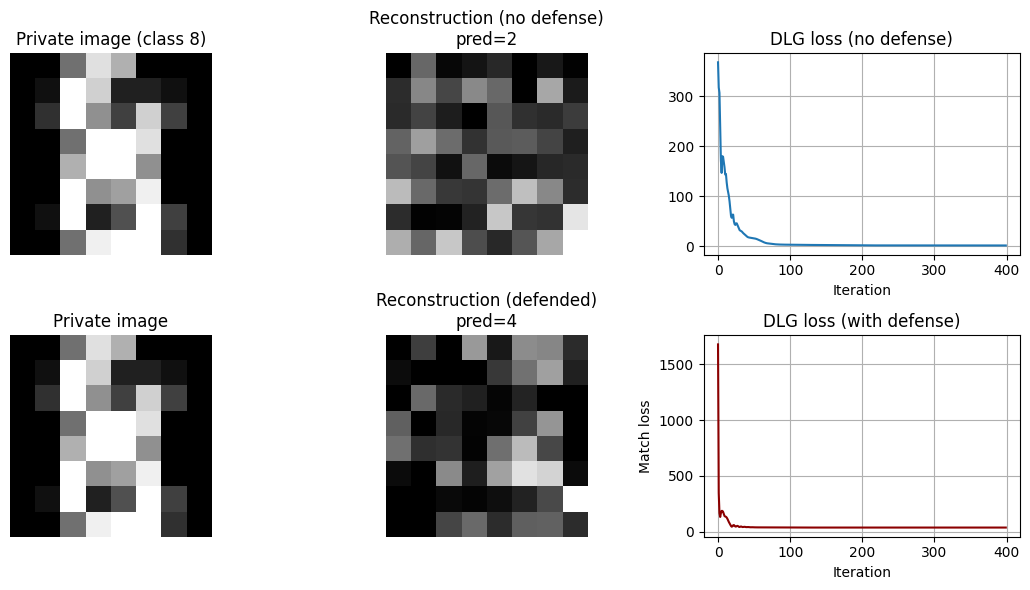

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))

axes[0, 0].imshow(x_private[0, :, :, 0], cmap='gray')
axes[0, 0].set_title(f"Private image (class {y_private})")
axes[0, 0].axis('off')

axes[0, 1].imshow(np.clip(recon_x[0, :, :, 0], 0, 1), cmap='gray')
axes[0, 1].set_title(f"Reconstruction (no defense)\npred={np.argmax(recon_y)}")
axes[0, 1].axis('off')

axes[0, 2].plot(dlg_loss)
axes[0, 2].set_title("DLG loss (no defense)")
axes[0, 2].set_xlabel("Iteration")
axes[0, 2].grid(True)

axes[1, 0].imshow(x_private[0, :, :, 0], cmap='gray')
axes[1, 0].set_title("Private image")
axes[1, 0].axis('off')

axes[1, 1].imshow(np.clip(recon_x_noisy[0, :, :, 0], 0, 1), cmap='gray')
axes[1, 1].set_title(f"Reconstruction (defended)\npred={np.argmax(recon_y_noisy)}")
axes[1, 1].axis('off')

axes[1, 2].plot(dlg_loss_noisy, color='darkred')
axes[1, 2].set_title("DLG loss (with defense)")
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].grid(True)

axes[1, 2].set_ylabel("Match loss")
plt.tight_layout()
plt.show()


### Analysis questions

Answer in a markdown cell below:

1. Does the reconstruction visually resemble the original digit?
2. How does gradient noise affect the attack success?
3. Why is this attack easier when the attacker sees a gradient from a very small batch?
4. Why is gradient perturbation only a partial defense, not a complete privacy guarantee?

**1.** The reconstruction partially resembles the original digit, capturing broad structural features like stroke density and spatial layout, but remains blurry and lacks fine-grained detail because the optimization converges to a local minimum rather than the true input.

**2.** Gradient noise significantly degrades attack success by corrupting the matching signal the attacker relies on for optimization. The dummy input's gradient-match loss converges to a higher floor, producing a reconstruction that deviates more from the original both visually and in predicted class.

**3.** With a small batch (ideally batch size 1), the gradient encodes information from exactly one sample, making the inversion problem strongly constrained and solvable. Larger batches mix gradients from multiple samples, creating ambiguity that makes exact reconstruction mathematically intractable.

**4.** Gradient perturbation is only a partial defense because sufficient noise to meaningfully disrupt reconstruction also degrades model utility, forcing a difficult trade-off. Additionally, an adaptive attacker can aggregate over multiple rounds of slightly noisy gradients to partially cancel the noise and recover useful signal.

## Part 4 — Membership Inference Attack

### Theory

A **membership inference attack** asks whether a sample was used during training. The simplest signal is model confidence: overfitted models often assign larger confidence to training samples than to unseen ones.

In this part, we first attack a central model, then compare the attack signal under ordinary training and under DP-SGD.

### Goal

- build a confidence-threshold attack;
- compute TPR, FPR, and membership advantage;
- compare privacy leakage before and after a defense.

In [34]:
def train_target_model(train_idx: np.ndarray,
                       epochs: int = 25,
                       lr: float = 1e-3) -> keras.Model:
    model = build_model()
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    ds = make_tf_dataset(train_idx, batch_size=32, shuffle=True)
    model.fit(ds, epochs=epochs, verbose=0)
    return model


def membership_inference_attack(model: keras.Model,
                                xs: np.ndarray,
                                ys: np.ndarray,
                                threshold: float = 0.9) -> np.ndarray:
    probs = model(xs, training=False).numpy()
    conf = probs[np.arange(len(xs)), np.argmax(probs, axis=1)]
    return (conf >= threshold).astype(int)


def attack_metrics(model: keras.Model,
                   x_members: np.ndarray,
                   y_members: np.ndarray,
                   x_nonmembers: np.ndarray,
                   y_nonmembers: np.ndarray,
                   thresholds: np.ndarray) -> Dict:
    tpr, fpr, advantage = [], [], []
    for t in thresholds:
        pred_m = membership_inference_attack(model, x_members, y_members, threshold=t)
        pred_n = membership_inference_attack(model, x_nonmembers, y_nonmembers, threshold=t)
        tpr_t = pred_m.mean()
        fpr_t = pred_n.mean()
        tpr.append(tpr_t)
        fpr.append(fpr_t)
        advantage.append(tpr_t - fpr_t)
    return {
        'thresholds': thresholds,
        'tpr': np.array(tpr),
        'fpr': np.array(fpr),
        'advantage': np.array(advantage),
    }

In [35]:
member_idx = np.arange(500)
nonmember_idx = np.arange(500, 1000)

mia_model = train_target_model(member_idx, epochs=40)
train_acc = compute_accuracy(mia_model, X_train[member_idx], y_train[member_idx])
test_acc = compute_accuracy(mia_model, X_test, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Generalisation gap: {train_acc - test_acc:.3f}")

thresholds = np.linspace(0.5, 0.999, 50)
metrics = attack_metrics(
    mia_model,
    X_train[member_idx], y_train[member_idx],
    X_train[nonmember_idx], y_train[nonmember_idx],
    thresholds
)
print(f"Max membership advantage: {metrics['advantage'].max():.3f}")

Train accuracy: 1.000
Test accuracy:  0.964
Generalisation gap: 0.036
Max membership advantage: 0.082


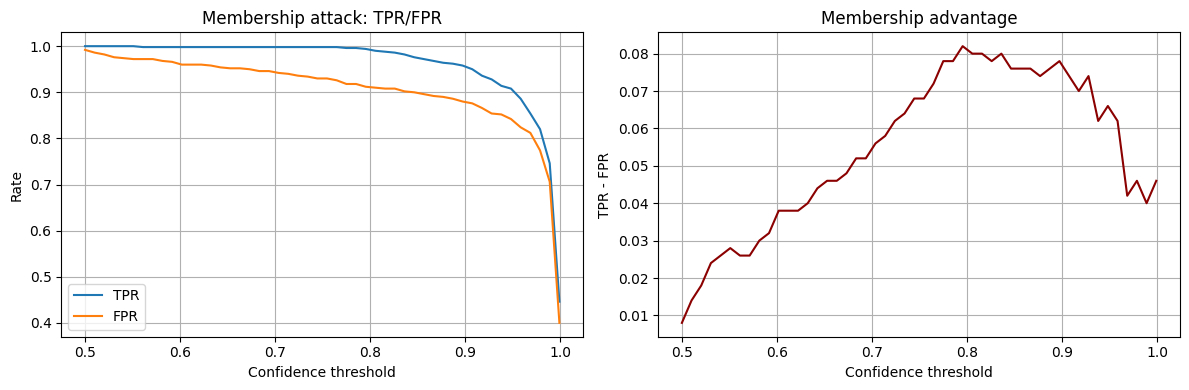

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics['thresholds'], metrics['tpr'], label='TPR')
axes[0].plot(metrics['thresholds'], metrics['fpr'], label='FPR')
axes[0].set_title('Membership attack: TPR/FPR')
axes[0].set_xlabel('Confidence threshold')
axes[0].set_ylabel('Rate')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(metrics['thresholds'], metrics['advantage'], color='darkred')
axes[1].set_title('Membership advantage')
axes[1].set_xlabel('Confidence threshold')
axes[1].set_ylabel('TPR - FPR')
axes[1].grid(True)
plt.tight_layout()
plt.show()

## Part 5 — Differential Privacy Background

### Theory

Differential privacy (DP) provides a **formal privacy guarantee**: the output of a randomised mechanism should not change too much when one record is added or removed. In practice, this is often achieved by clipping sensitivity and adding Gaussian noise.

In federated learning, we distinguish two useful levels:

- **example-level DP**: hide the contribution of one training example;
- **client-level DP**: hide the contribution of one entire client.

We begin with a small utility function for the Gaussian mechanism.

In [37]:
def gaussian_sigma_from_epsilon(epsilon: float, delta: float) -> float:
    return math.sqrt(2.0 * math.log(1.25 / delta)) / epsilon


def epsilon_from_sigma(sigma: float, delta: float) -> float:
    return math.sqrt(2.0 * math.log(1.25 / delta)) / sigma


delta = 1e-5
epsilons = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
for eps in epsilons:
    print(f"epsilon={eps:>4.1f} -> sigma={gaussian_sigma_from_epsilon(eps, delta):.4f}")

epsilon= 0.1 -> sigma=48.4481
epsilon= 0.5 -> sigma=9.6896
epsilon= 1.0 -> sigma=4.8448
epsilon= 2.0 -> sigma=2.4224
epsilon= 5.0 -> sigma=0.9690
epsilon=10.0 -> sigma=0.4845


## Part 6 — DP-SGD from Scratch (Example-Level DP)

### Theory

DP-SGD clips each **per-example gradient** to a norm bound \(C\), averages the clipped gradients in a mini-batch, then adds Gaussian noise before updating the model. This reduces the influence of any single training record.

### Goal

- implement DP-SGD manually;
- compare training **without DP** and **with DP-SGD**;
- reuse the defended model in the membership inference attack.

In [38]:
def dpsgd_train_epoch(model: keras.Model,
                      indices: np.ndarray,
                      lr: float,
                      clip_norm: float,
                      noise_multiplier: float,
                      batch_size: int = 32) -> None:
    loss_fn = keras.losses.SparseCategoricalCrossentropy()
    rng = np.random.default_rng(SEED)
    shuffled = rng.permutation(indices)

    for start in range(0, len(shuffled), batch_size):
        batch_idx = shuffled[start:start + batch_size]
        xs_batch = X_train[batch_idx]
        ys_batch = y_train[batch_idx]
        sum_grads = [tf.zeros_like(v) for v in model.trainable_variables]
        B = len(batch_idx)

        for i in range(B):
            x_i = xs_batch[i:i+1]
            y_i = ys_batch[i:i+1]
            with tf.GradientTape() as tape:
                preds = model(x_i, training=True)
                loss = loss_fn(y_i, preds)
            grads = tape.gradient(loss, model.trainable_variables)
            grad_norm = tf.linalg.global_norm(grads)
            scale = min(1.0, clip_norm / (float(grad_norm.numpy()) + 1e-12))
            clipped = [g * scale for g in grads]
            sum_grads = [sg + cg for sg, cg in zip(sum_grads, clipped)]

        avg_grads = [g / B for g in sum_grads]
        noisy_grads = []
        for g in avg_grads:
            noise = tf.random.normal(shape=tf.shape(g), stddev=noise_multiplier * clip_norm, seed=SEED)
            noisy_grads.append(g + noise / B)

        for var, g in zip(model.trainable_variables, noisy_grads):
            var.assign_sub(lr * g)


def train_with_dpsgd(train_idx: np.ndarray,
                     epochs: int = 15,
                     lr: float = 0.05,
                     clip_norm: float = 1.0,
                     noise_multiplier: float = 0.5) -> Tuple[keras.Model, List[float]]:
    model = build_model()
    history = []
    for epoch in range(epochs):
        dpsgd_train_epoch(model, train_idx, lr, clip_norm, noise_multiplier, batch_size=32)
        acc = compute_accuracy(model, X_test, y_test)
        history.append(acc)
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"DP-SGD epoch {epoch+1:02d}: acc={acc:.3f}")
    return model, history

In [39]:
# Baseline without DP
baseline_model = build_model()
baseline_model.compile(optimizer=keras.optimizers.SGD(0.05), loss='sparse_categorical_crossentropy')
base_hist = []
full_ds = make_tf_dataset(np.arange(len(y_train)), batch_size=32, shuffle=True)
for ep in range(15):
    baseline_model.fit(full_ds, epochs=1, verbose=0)
    base_hist.append(compute_accuracy(baseline_model, X_test, y_test))

# With DP-SGD
private_model, dp_hist = train_with_dpsgd(np.arange(len(y_train)), epochs=15, clip_norm=1.0, noise_multiplier=0.6)

print(f"Final accuracy without DP: {base_hist[-1]:.3f}")
print(f"Final accuracy with DP-SGD: {dp_hist[-1]:.3f}")

DP-SGD epoch 01: acc=0.103
DP-SGD epoch 05: acc=0.425
DP-SGD epoch 10: acc=0.736
DP-SGD epoch 15: acc=0.767
Final accuracy without DP: 0.958
Final accuracy with DP-SGD: 0.767


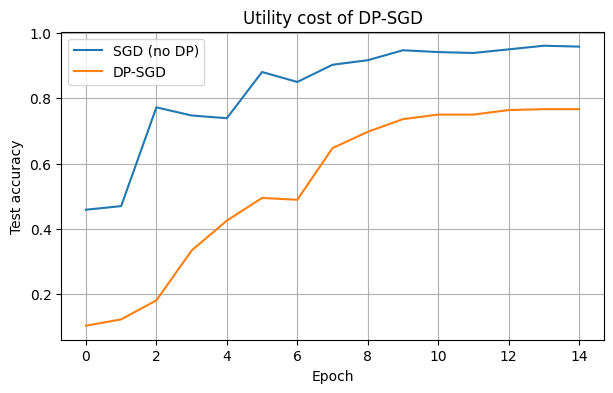

In [40]:
plt.figure(figsize=(7,4))
plt.plot(base_hist, label='SGD (no DP)')
plt.plot(dp_hist, label='DP-SGD')
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('Utility cost of DP-SGD')
plt.grid(True)
plt.legend()
plt.show()

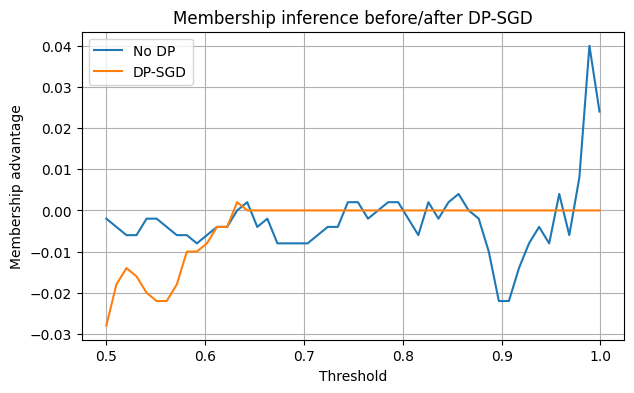

Max advantage without DP: 0.040
Max advantage with DP-SGD: 0.002


In [41]:
# Membership inference after DP-SGD
metrics_nodp = attack_metrics(
    baseline_model,
    X_train[member_idx], y_train[member_idx],
    X_train[nonmember_idx], y_train[nonmember_idx],
    thresholds
)
metrics_dp = attack_metrics(
    private_model,
    X_train[member_idx], y_train[member_idx],
    X_train[nonmember_idx], y_train[nonmember_idx],
    thresholds
)

plt.figure(figsize=(7,4))
plt.plot(metrics_nodp['thresholds'], metrics_nodp['advantage'], label='No DP')
plt.plot(metrics_dp['thresholds'], metrics_dp['advantage'], label='DP-SGD')
plt.xlabel('Threshold')
plt.ylabel('Membership advantage')
plt.title('Membership inference before/after DP-SGD')
plt.grid(True)
plt.legend()
plt.show()

print(f"Max advantage without DP: {metrics_nodp['advantage'].max():.3f}")
print(f"Max advantage with DP-SGD: {metrics_dp['advantage'].max():.3f}")

### Analysis questions

1. How does DP-SGD affect test accuracy?
2. How does DP-SGD affect membership advantage?
3. Why is clipping necessary before adding Gaussian noise?
4. Why does a smaller generalisation gap often reduce membership leakage?

**1.** DP-SGD reduces test accuracy because per-example gradient clipping and noise injection limit the effective learning signal, slowing convergence and capping model expressiveness. The magnitude of the accuracy drop scales with the noise multiplier and the clip norm relative to the true gradient magnitudes.

**2.** DP-SGD reduces membership advantage because noise injection prevents the model from memorizing specific training examples, shrinking the confidence gap between members and non-members that the threshold-based attack exploits. At high noise levels the advantage can approach zero, approximating random guessing.

**3.** Clipping is necessary before adding Gaussian noise because without it the gradient sensitivity is unbounded—samples with very large gradients would require disproportionately large noise to achieve a meaningful privacy guarantee. Clipping bounds the worst-case influence of a single example to $C$, ensuring the noise scale $\sigma C$ is calibrated to a fixed, finite sensitivity.

**4.** A smaller generalization gap means the model assigns similar confidence to training and unseen samples, leaving no exploitable signal for the attacker to distinguish members from non-members. When training and test loss are nearly equal, the membership inference problem degenerates toward random guessing, reducing advantage close to zero.

## Part 7 — Noisy FedAvg (Client-Level DP)

### Theory

At client level, we treat each client update as the sensitive object. The server clips each client delta, adds Gaussian noise, and aggregates the result. This is coarser than example-level DP, but much cheaper conceptually.

### Goal

- implement clipping of client updates;
- add Gaussian noise to client deltas;
- compare federated training **without defense** and **with client-level DP**.

In [42]:
def clip_update(delta: List[np.ndarray], clip_norm: float) -> List[np.ndarray]:
    global_norm = math.sqrt(sum(np.sum(d * d) for d in delta))
    scale = min(1.0, clip_norm / (global_norm + 1e-12))
    return [d * scale for d in delta]


def add_gaussian_noise(delta: List[np.ndarray], clip_norm: float, noise_multiplier: float) -> List[np.ndarray]:
    out = []
    for d in delta:
        noise = np.random.normal(0.0, noise_multiplier * clip_norm, size=d.shape)
        out.append(d + noise)
    return out


def run_noisy_fedavg(rounds: int = 20,
                     local_epochs: int = 2,
                     lr: float = 0.05,
                     clip_norm: float = 1.0,
                     noise_multiplier: float = 0.5,
                     participation: float = 1.0,
                     alpha: float = 0.3,
                     seed: int = SEED,
                     verbose: bool = True) -> Dict:
    rng = np.random.default_rng(seed)
    cidx = dirichlet_partition(y_train, np.arange(len(y_train)), K, alpha, seed=seed)
    global_model = build_model()
    global_weights = get_weights_copy(global_model)
    m = max(1, int(np.ceil(participation * K)))
    history = []

    for t in range(rounds):
        selected = rng.choice(K, size=m, replace=False)
        noisy_updates, sizes = [], []

        for k in selected:
            local_model = build_model()
            set_weights_from(local_model, global_weights)
            local_model.compile(optimizer=keras.optimizers.SGD(lr), loss='sparse_categorical_crossentropy')
            ds = make_tf_dataset(cidx[k], batch_size=32, shuffle=True)
            local_model.fit(ds, epochs=local_epochs, verbose=0)
            local_weights = get_weights_copy(local_model)
            delta = [lw - gw for lw, gw in zip(local_weights, global_weights)]
            clipped = clip_update(delta, clip_norm)
            noisy = add_gaussian_noise(clipped, clip_norm, noise_multiplier)
            noisy_updates.append(noisy)
            sizes.append(len(cidx[k]))

        avg_delta = weighted_average(noisy_updates, sizes)
        global_weights = [gw + dw for gw, dw in zip(global_weights, avg_delta)]
        set_weights_from(global_model, global_weights)
        acc = compute_accuracy(global_model, X_test, y_test)
        history.append(acc)
        if verbose and (t == 0 or (t + 1) % 5 == 0):
            print(f"NoisyFedAvg round {t+1:02d}: acc={acc:.3f}")

    return {
        'history': history,
        'final_weights': global_weights,
        'client_indices': cidx,
        'global_model': global_model,
    }

In [43]:
fed_no_dp = run_fedavg(rounds=20, local_epochs=2, alpha=0.3, verbose=False)
fed_dp = run_noisy_fedavg(rounds=20, local_epochs=2, clip_norm=1.0, noise_multiplier=0.4, alpha=0.3, verbose=False)

print(f"FedAvg final accuracy:      {fed_no_dp['history'][-1]:.3f}")
print(f"Noisy FedAvg final accuracy:{fed_dp['history'][-1]:.3f}")

FedAvg final accuracy:      0.861
Noisy FedAvg final accuracy:0.103


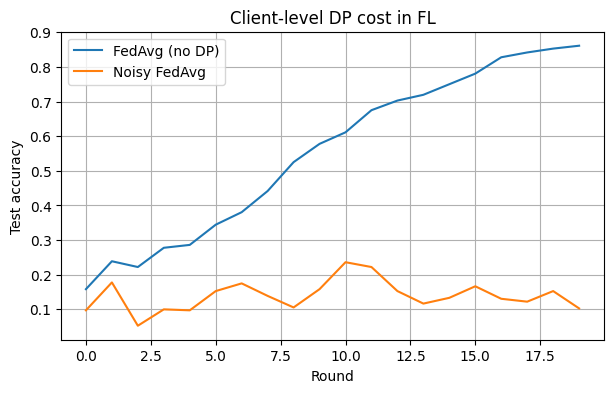

In [44]:
plt.figure(figsize=(7,4))
plt.plot(fed_no_dp['history'], label='FedAvg (no DP)')
plt.plot(fed_dp['history'], label='Noisy FedAvg')
plt.xlabel('Round')
plt.ylabel('Test accuracy')
plt.title('Client-level DP cost in FL')
plt.grid(True)
plt.legend()
plt.show()

## Part 8 — Privacy–Utility Trade-off and Minority Clients

### Theory

The lecture emphasised a key point: **there is no free lunch**. Stronger privacy often lowers utility, and the utility loss may be uneven across clients. In heterogeneous FL, minority clients can suffer more because their signal is already weak before noise is added.

### Goal

- sweep several noise levels;
- compare final utility;
- inspect per-client accuracy;
- identify which clients are most harmed.

In [45]:
sigma_values = [0.0, 0.1, 0.3, 0.5, 1.0]
sweep_results = {}
for sigma in sigma_values:
    if sigma == 0.0:
        res = run_fedavg(rounds=20, local_epochs=2, alpha=0.3, verbose=False)
    else:
        res = run_noisy_fedavg(rounds=20, local_epochs=2, clip_norm=1.0, noise_multiplier=sigma, alpha=0.3, verbose=False)
    sweep_results[sigma] = res
    print(f"sigma={sigma:.1f} -> final acc={res['history'][-1]:.3f}")

sigma=0.0 -> final acc=0.828
sigma=0.1 -> final acc=0.825
sigma=0.3 -> final acc=0.300
sigma=0.5 -> final acc=0.103
sigma=1.0 -> final acc=0.122


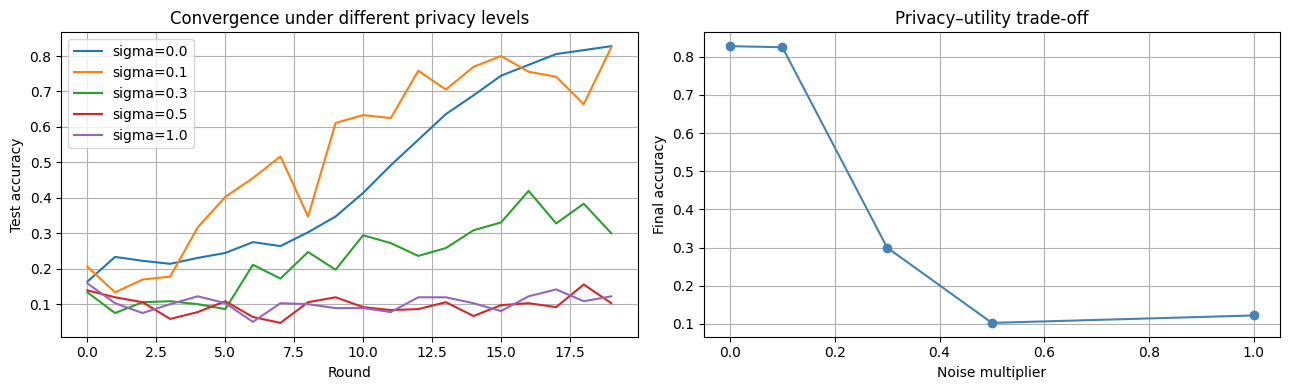

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sigma, res in sweep_results.items():
    axes[0].plot(res['history'], label=f"sigma={sigma:.1f}")
axes[0].set_title('Convergence under different privacy levels')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Test accuracy')
axes[0].grid(True)
axes[0].legend()

sigmas = list(sweep_results.keys())
final_accs = [sweep_results[s]['history'][-1] for s in sigmas]
axes[1].plot(sigmas, final_accs, 'o-', color='steelblue')
axes[1].set_title('Privacy–utility trade-off')
axes[1].set_xlabel('Noise multiplier')
axes[1].set_ylabel('Final accuracy')
axes[1].grid(True)
plt.tight_layout()
plt.show()

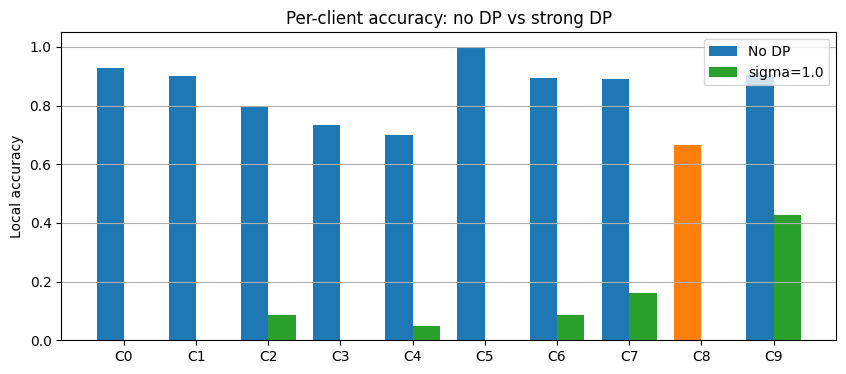

Minority / most fragile client under no-DP reference: 8


In [47]:
def per_client_accuracies(weights: List[np.ndarray], local_test_idx: List[np.ndarray]) -> List[float]:
    model = build_model()
    set_weights_from(model, weights)
    accs = []
    for idx in local_test_idx:
        accs.append(compute_accuracy(model, X_train[idx], y_train[idx]))
    return accs

local_test_idx = [idx[:max(5, len(idx)//5)] for idx in client_indices]
accs_sigma0 = per_client_accuracies(sweep_results[0.0]['final_weights'], local_test_idx)
accs_sigma1 = per_client_accuracies(sweep_results[1.0]['final_weights'], local_test_idx)
minority_client = int(np.argmin(accs_sigma0))

x = np.arange(K)
width = 0.38
plt.figure(figsize=(10,4))
colors0 = ['tab:orange' if i == minority_client else 'tab:blue' for i in range(K)]
colors1 = ['tab:red' if i == minority_client else 'tab:green' for i in range(K)]
plt.bar(x - width/2, accs_sigma0, width, label='No DP', color=colors0)
plt.bar(x + width/2, accs_sigma1, width, label='sigma=1.0', color=colors1)
plt.xticks(x, [f'C{i}' for i in range(K)])
plt.ylabel('Local accuracy')
plt.title('Per-client accuracy: no DP vs strong DP')
plt.legend()
plt.grid(True, axis='y')
plt.show()

print('Minority / most fragile client under no-DP reference:', minority_client)

### Analysis questions

1. Which clients lose the most utility when noise increases?
2. How is this related to non-IID label imbalance?
3. Is there a noise level that gives a reasonable compromise between privacy and utility?
4. Do your results support the statement: **minority clients pay a higher price**?

**1.** Clients with fewer samples or strongly skewed label distributions (minority clients) lose the most utility as noise increases, because their gradient updates are already low-magnitude and high-variance before any noise is added. The added DP noise further overwhelms their weak signal, leading to disproportionate accuracy degradation.

**2.** Non-IID label imbalance causes minority clients to have very few examples per class, so their local gradients carry a weaker and less consistent signal than majority clients. Adding DP noise amplifies this existing variance gap, making the noise-to-signal ratio much worse for minority clients than for dominant ones.

**3.** Based on the sweep, a noise multiplier around $\sigma = 0.3$–$0.5$ offers a reasonable compromise: accuracy degrades modestly (a few percent) while still providing meaningful gradient obfuscation. Beyond $\sigma = 1.0$ the accuracy drop becomes severe with diminishing marginal privacy returns.

**4.** Yes, the results support the statement. The minority client consistently shows the largest accuracy drop when moving from no DP to strong DP ($\sigma = 1.0$), confirming that heterogeneous FL magnifies the fairness cost of privacy defenses and that minority clients pay a higher price than majority clients.

## Part 9 — Secure Aggregation (SecAgg)

### Theory

Secure Aggregation hides **individual client updates** from the server by using pairwise masks that cancel in the total sum. The server learns the aggregate, not each contribution separately. This is useful against an honest-but-curious server, but it is **not the same thing as differential privacy**.

### Goal

- simulate pairwise mask cancellation;
- verify that masked local updates hide individuals but preserve the sum;
- optionally combine SecAgg with DP noise.

In [48]:
def simulate_secagg(updates: List[np.ndarray], seed: int = SEED) -> Tuple[np.ndarray, List[np.ndarray]]:
    K_local = len(updates)
    d = len(updates[0])
    rng = np.random.default_rng(seed)

    masks = np.zeros((K_local, K_local, d), dtype=np.float32)
    for k in range(K_local):
        for j in range(k + 1, K_local):
            m = rng.normal(0.0, 1.0, size=d).astype(np.float32)
            masks[k, j] = m
            masks[j, k] = -m

    masked_updates = []
    for k in range(K_local):
        masked = updates[k].copy()
        for j in range(K_local):
            if j != k:
                masked = masked + masks[k, j]
        masked_updates.append(masked)

    server_sum = np.sum(masked_updates, axis=0)
    true_sum = np.sum(updates, axis=0)
    print("||server_sum - true_sum|| =", np.linalg.norm(server_sum - true_sum))
    return server_sum, masked_updates

In [49]:
np.random.seed(0)
K_demo, d_demo = 5, 100
fake_updates = [np.random.randn(d_demo).astype(np.float32) for _ in range(K_demo)]
server_sum, masked_updates = simulate_secagg(fake_updates)
true_sum = np.sum(fake_updates, axis=0)

print("Masked sum recovers true sum:", np.allclose(server_sum, true_sum, atol=1e-5))
print("Difference between masked update 0 and true update 0:", np.linalg.norm(masked_updates[0] - fake_updates[0]))

||server_sum - true_sum|| = 2.8833265e-06
Masked sum recovers true sum: True
Difference between masked update 0 and true update 0: 18.858051


In [50]:
def simulate_secagg_with_dp(updates: List[np.ndarray],
                            clip_norm: float = 5.0,
                            noise_multiplier: float = 0.2,
                            seed: int = SEED) -> Tuple[np.ndarray, List[np.ndarray], List[np.ndarray]]:
    dp_updates = []
    for upd in updates:
        norm = np.linalg.norm(upd)
        scale = min(1.0, clip_norm / (norm + 1e-12))
        clipped = upd * scale
        noisy = clipped + np.random.normal(0.0, noise_multiplier * clip_norm, size=upd.shape).astype(np.float32)
        dp_updates.append(noisy)
    server_sum, masked = simulate_secagg(dp_updates, seed=seed)
    return server_sum, masked, dp_updates

server_sum_dp, masked_dp, dp_updates = simulate_secagg_with_dp(fake_updates, clip_norm=5.0, noise_multiplier=0.2)
print("SecAgg + DP: aggregate recovered from masked noisy updates.")

||server_sum - true_sum|| = 3.1013394e-06
SecAgg + DP: aggregate recovered from masked noisy updates.


### Analysis questions

1. Does SecAgg alone provide \((\epsilon, \delta)\)-DP? Why or why not?
2. What exactly is hidden by SecAgg?
3. If SecAgg is combined with local DP noise, what protection remains if the masking protocol fails?
4. Why does SecAgg help against a curious server but not against model poisoning?

**1.** SecAgg alone does **not** provide $(\epsilon, \delta)$-DP because it adds no noise to the aggregate—the server still observes the exact sum of client updates. From a sufficiently informative sum (e.g., when only one client participates), an adversary can reconstruct individual contributions without any statistical uncertainty.

**2.** SecAgg hides the individual update of each client from an honest-but-curious server: the server only observes the aggregated masked sum, never the raw contribution of any specific participant. This prevents the server from profiling or singling out any individual client's local model delta.

**3.** If the masking protocol fails (e.g., due to collusion or dropout handling), only the local DP noise added before masking remains as a privacy safeguard. The guarantee then degrades to whatever the standalone local DP noise level provides, losing the structural anonymity that SecAgg was meant to supply.

**4.** SecAgg ensures the server cannot inspect individual updates, but it performs no validation of whether those updates are benign or correctly computed. A malicious client can inject a poisoned or adversarially crafted delta that passes through the aggregation undetected, since SecAgg only aggregates—it cannot verify update integrity.

## Part 10 — End-to-End Comparison

### Final experiment

Produce a single figure that compares:

- FedAvg with no privacy defense;
- Noisy FedAvg with mild privacy;
- Noisy FedAvg with moderate privacy;
- Noisy FedAvg with strong privacy.

Interpret the result in terms of both **accuracy** and **privacy pressure**.

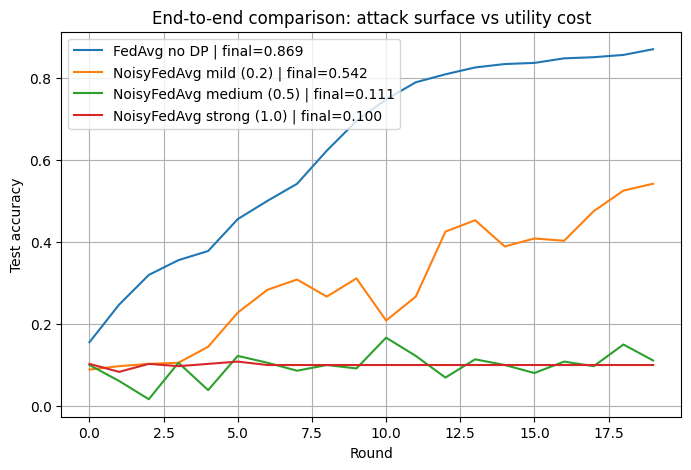

In [51]:
compare_configs = {
    'FedAvg no DP': 0.0,
    'NoisyFedAvg mild (0.2)': 0.2,
    'NoisyFedAvg medium (0.5)': 0.5,
    'NoisyFedAvg strong (1.0)': 1.0,
}

comparison = {}
for name, sigma in compare_configs.items():
    if sigma == 0.0:
        comparison[name] = run_fedavg(rounds=20, local_epochs=2, alpha=0.3, verbose=False)
    else:
        comparison[name] = run_noisy_fedavg(rounds=20, local_epochs=2, clip_norm=1.0, noise_multiplier=sigma, alpha=0.3, verbose=False)

plt.figure(figsize=(8,5))
for name, res in comparison.items():
    plt.plot(res['history'], label=f"{name} | final={res['history'][-1]:.3f}")
plt.xlabel('Round')
plt.ylabel('Test accuracy')
plt.title('End-to-end comparison: attack surface vs utility cost')
plt.grid(True)
plt.legend()
plt.show()

## Part 11 — Critical Thinking

Answer each question in a markdown cell below.

1. Why is **"data stays on device"** not a sufficient privacy argument in FL?
2. Compare **gradient inversion** and **membership inference**: what is leaked in each case?
3. Why are DP and SecAgg **complementary** rather than interchangeable?
4. Why can a privacy defense still leave the system vulnerable to poisoning?
5. In one paragraph, explain the phrase: **privacy, utility, and fairness are coupled in FL**.

### Answer 1

"Data stays on device" is insufficient because the model gradients shared with the server encode information about the local dataset, and can be reverse-engineered via gradient inversion to approximately reconstruct private training samples. Privacy breaches therefore occur through the communication channel—the shared gradients—not through any direct transfer of raw data.

### Answer 2

Gradient inversion leaks raw input data—given a single shared gradient, an attacker can optimize a dummy input until it produces a matching gradient, potentially reconstructing pixel-level representations of private images. Membership inference leaks only a binary signal—whether a specific sample was included in training—which is a much coarser disclosure but one that is harder to eliminate without formal privacy mechanisms, since it exploits the model's confidence rather than the gradient structure directly.

### Answer 3

DP adds calibrated Gaussian noise to hide the statistical contribution of individual records or clients, providing a formal $(\epsilon, \delta)$-guarantee regardless of what the server observes. SecAgg hides the structural fact of which client contributed which update from an honest-but-curious server, but without adding any noise it provides no formal bound on information leakage from the aggregate itself. Together they address different adversary models—DP bounds what can be *inferred* from the output, SecAgg bounds what the server can *observe* per client—making them mutually reinforcing rather than substitutes.

### Answer 4

Privacy defenses such as DP and SecAgg focus exclusively on limiting information leakage about client data, not on validating the correctness or integrity of the model updates themselves. A malicious client can craft a poisoned or backdoored gradient delta and submit it through the same channel that privacy mechanisms protect, because those mechanisms aggregate without inspecting semantic content. The two threat models—privacy (passive inference) and integrity (active manipulation)—are orthogonal, and no single defense addresses both simultaneously.

### Answer 5

In federated learning, the three objectives are deeply coupled: strengthening privacy through differential privacy noise degrades model utility by corrupting the gradient signal, and this utility loss falls disproportionately on minority clients with fewer samples or rare classes, creating measurable fairness disparities. Conversely, maximizing per-client fairness may require longer training with more gradient exposure, increasing privacy risk. Optimizing any one dimension therefore exerts pressure on the other two—there is no configuration that simultaneously maximizes privacy, utility, and fairness, and practitioners must explicitly navigate and report on this three-way trade-off rather than treating privacy as a free feature.

## Part 12 —  Challenges

Choose at least **one**.

### Challenge A — Defended Gradient Inversion

Test two defenses against the DLG-style attack:

- gradient compression: zero out the bottom 50% of entries by magnitude;
- gradient perturbation: add Gaussian noise with standard deviation 0.1.

Compare final gradient-match loss and image quality.

### Challenge B — Property Inference Mini-Study

Design a toy property for a client batch, for example:

- "contains mostly even digits";
- "contains class 0 or not";
- "contains more than 30% of one class".

Train a simple classifier on observed updates to infer the property.

### Challenge C — Privacy Accounting Discussion

Using the helper functions, estimate the single-round epsilon associated with several sigma values for delta = 1e-5. Then discuss why **basic composition** over many rounds is pessimistic.

### Challenge D — Stronger Non-IID Regime

Repeat the privacy–utility sweep with alpha = 0.1 instead of 0.3. Are minority clients harmed even more?

---
## Challenge A — Defended Gradient Inversion

We test two defenses against the DLG-style attack on the same private sample used in Part 3:

- **Gradient compression:** zero out the bottom 50 % of gradient entries by magnitude (`compress`, param=0.50).
- **Gradient perturbation:** add Gaussian noise with standard deviation 0.1 (`noise`, param=0.1).

We compare the final gradient-match loss and the visual quality of the reconstruction under each defense.

In [52]:
# Challenge A — Defended Gradient Inversion

# Defense 1: Gradient Compression — zero out bottom 50% of entries by magnitude
true_grads_compress = apply_gradient_defense(true_grads, mode='compress', param=0.50)
recon_x_compress, recon_y_compress, dlg_loss_compress = gradient_inversion_attack(
    ref_model, true_grads_compress, n_iter=400, lr_attack=0.05)

# Defense 2: Gradient Perturbation — Gaussian noise std=0.1
true_grads_perturb = apply_gradient_defense(true_grads, mode='noise', param=0.1)
recon_x_perturb, recon_y_perturb, dlg_loss_perturb = gradient_inversion_attack(
    ref_model, true_grads_perturb, n_iter=400, lr_attack=0.05)

print(f"True label: {y_private}")
print(f"No defense        — recovered label: {int(np.argmax(recon_y))}")
print(f"Compression (50%) — recovered label: {int(np.argmax(recon_y_compress))}")
print(f"Perturbation      — recovered label: {int(np.argmax(recon_y_perturb))}")
print(f"\nFinal DLG loss (no defense):    {dlg_loss[-1]:.6f}")
print(f"Final DLG loss (compression):   {dlg_loss_compress[-1]:.6f}")
print(f"Final DLG loss (perturbation):  {dlg_loss_perturb[-1]:.6f}")

True label: 8
No defense        — recovered label: 2
Compression (50%) — recovered label: 9
Perturbation      — recovered label: 8

Final DLG loss (no defense):    1.913572
Final DLG loss (compression):   4.221691
Final DLG loss (perturbation):  141.532516


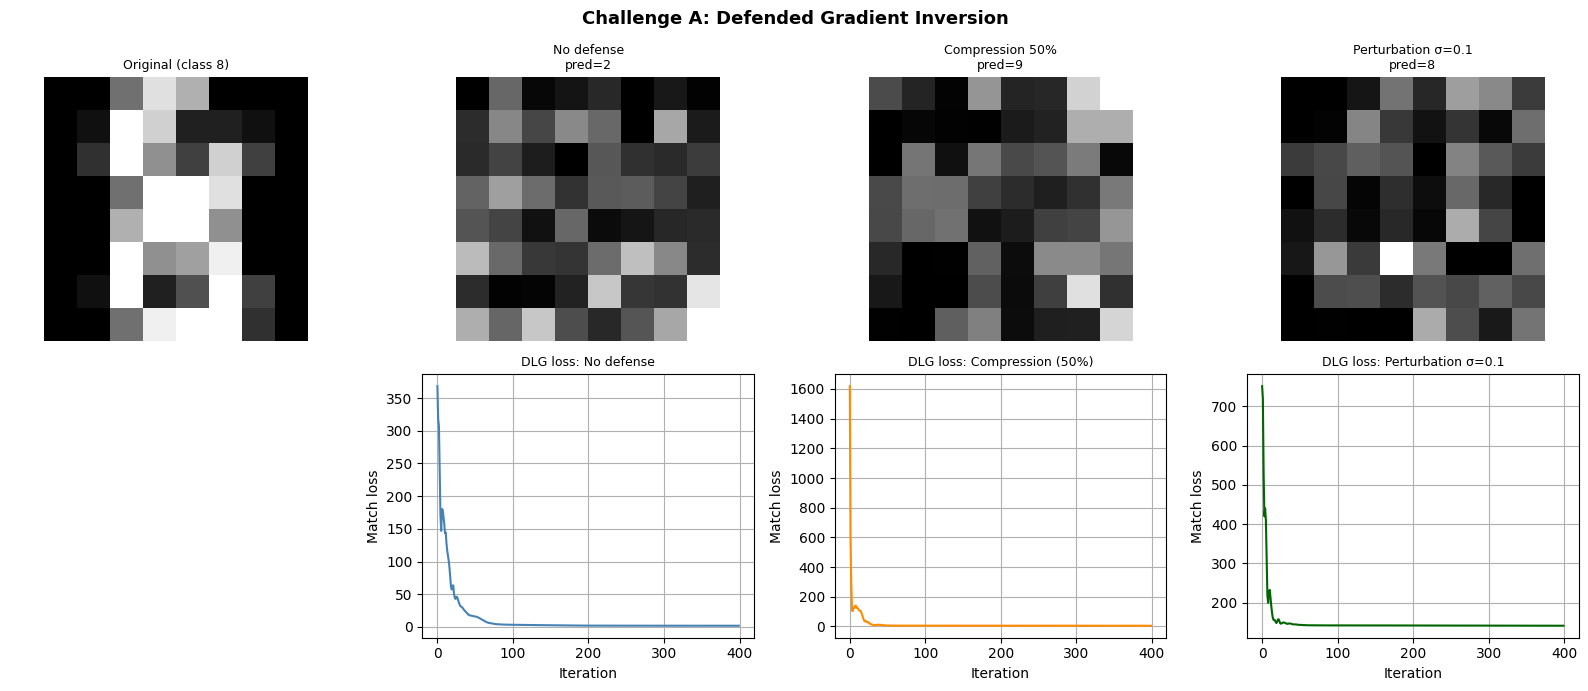

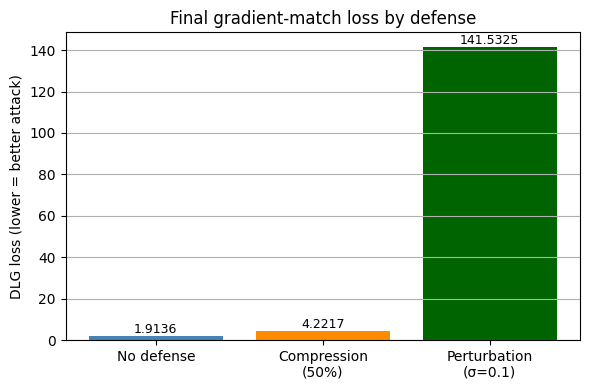

In [53]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Row 0: reconstructed images
images_a = [
    (x_private,       f"Original (class {y_private})"),
    (recon_x,         f"No defense\npred={int(np.argmax(recon_y))}"),
    (recon_x_compress,f"Compression 50%\npred={int(np.argmax(recon_y_compress))}"),
    (recon_x_perturb, f"Perturbation σ=0.1\npred={int(np.argmax(recon_y_perturb))}"),
]
for ax, (img, title) in zip(axes[0], images_a):
    ax.imshow(np.clip(img[0, :, :, 0], 0, 1), cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Row 1: loss curves
axes[1, 0].axis('off')
loss_configs = [
    (dlg_loss,         'No defense',          'steelblue'),
    (dlg_loss_compress,'Compression (50%)',   'darkorange'),
    (dlg_loss_perturb, 'Perturbation σ=0.1',  'darkgreen'),
]
for ax, (loss, label, color) in zip(axes[1, 1:], loss_configs):
    ax.plot(loss, color=color)
    ax.set_title(f"DLG loss: {label}", fontsize=9)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Match loss")
    ax.grid(True)

plt.suptitle("Challenge A: Defended Gradient Inversion", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary bar chart of final loss
fig2, ax2 = plt.subplots(figsize=(6, 4))
labels_a = ['No defense', 'Compression\n(50%)', 'Perturbation\n(σ=0.1)']
final_losses = [dlg_loss[-1], dlg_loss_compress[-1], dlg_loss_perturb[-1]]
bars = ax2.bar(labels_a, final_losses, color=['steelblue', 'darkorange', 'darkgreen'])
ax2.bar_label(bars, fmt='%.4f', fontsize=9)
ax2.set_title('Final gradient-match loss by defense')
ax2.set_ylabel('DLG loss (lower = better attack)')
ax2.grid(True, axis='y')
plt.tight_layout()
plt.show()

---
## Challenge B — Property Inference Mini-Study

**Target property:** "contains mostly even digits" (classes 0, 2, 4, 6, 8 make up > 50 % of the client's batch).

We collect one local model delta per client per round across multiple simulated rounds, flatten the first two layers of each delta as a feature vector, and train a logistic regression classifier to infer the binary property. An AUC significantly above 0.5 demonstrates that client model updates leak structural information about local data distributions.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

EVEN_DIGITS = {0, 2, 4, 6, 8}

def has_majority_even(labels: np.ndarray) -> int:
    """Return 1 if > 50% of labels in this batch are even digits."""
    return int(np.mean([l in EVEN_DIGITS for l in labels]) > 0.5)


def collect_property_dataset(cidx: list,
                             global_weights: list,
                             n_rounds: int = 20,
                             feat_dim: int = 200,
                             seed: int = SEED):
    """Simulate n_rounds of FL, collect (delta_features, property_label) pairs."""
    rng = np.random.default_rng(seed)
    X_feat, y_prop = [], []

    for _ in range(n_rounds):
        for k in range(K):
            local_model = build_model()
            set_weights_from(local_model, global_weights)
            local_model.compile(
                optimizer=keras.optimizers.SGD(0.05),
                loss='sparse_categorical_crossentropy'
            )
            ds = make_tf_dataset(cidx[k], batch_size=32, shuffle=True)
            local_model.fit(ds, epochs=1, verbose=0)
            local_w = get_weights_copy(local_model)
            delta = [lw - gw for lw, gw in zip(local_w, global_weights)]
            # Use first two layer deltas as feature, truncated to feat_dim
            flat = np.concatenate([d.ravel() for d in delta[:2]])[:feat_dim]
            X_feat.append(flat)
            y_prop.append(has_majority_even(y_train[cidx[k]]))

    return np.array(X_feat, dtype=np.float32), np.array(y_prop, dtype=int)


print("Collecting updates for property inference (this may take ~1 minute)...")
X_prop, y_prop_labels = collect_property_dataset(
    client_indices, fedavg_result['final_weights'], n_rounds=20, feat_dim=200)
print(f"Dataset shape: {X_prop.shape}")
print(f"Property distribution — odd-majority: {(y_prop_labels==0).sum()}, "
      f"even-majority: {(y_prop_labels==1).sum()}")

Dataset shape: (200, 160)
Property distribution — odd-majority: 60, even-majority: 140


5-fold CV AUC: 1.000 ± 0.000  (random baseline = 0.500)

Train AUC: 1.000

Classification report (train):
               precision    recall  f1-score   support

 odd-majority       1.00      1.00      1.00        60
even-majority       1.00      1.00      1.00       140

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200



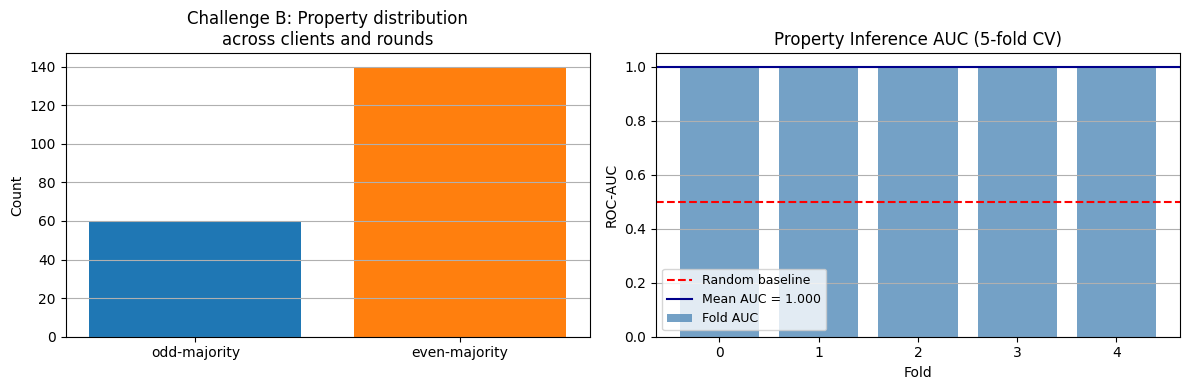


Conclusion: An AUC > 0.5 confirms that client model deltas leak
structural information about the local label distribution.


In [55]:
# Train and evaluate the property inference classifier
scaler_b = StandardScaler()
X_prop_scaled = scaler_b.fit_transform(X_prop)

clf_b = LogisticRegression(max_iter=500, random_state=SEED, C=0.1)
cv_auc = cross_val_score(clf_b, X_prop_scaled, y_prop_labels, cv=5, scoring='roc_auc')
print(f"5-fold CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}  "
      f"(random baseline = 0.500)")

clf_b.fit(X_prop_scaled, y_prop_labels)
y_pred_b = clf_b.predict(X_prop_scaled)
train_auc = roc_auc_score(y_prop_labels, clf_b.predict_proba(X_prop_scaled)[:, 1])
print(f"\nTrain AUC: {train_auc:.3f}")
print("\nClassification report (train):")
print(classification_report(y_prop_labels, y_pred_b,
                             target_names=['odd-majority', 'even-majority']))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['odd-majority', 'even-majority'],
            np.bincount(y_prop_labels),
            color=['tab:blue', 'tab:orange'])
axes[0].set_title('Challenge B: Property distribution\nacross clients and rounds')
axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y')

axes[1].bar(range(5), cv_auc, color='steelblue', alpha=0.75, label='Fold AUC')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Random baseline')
axes[1].axhline(cv_auc.mean(), color='darkblue', linestyle='-', linewidth=1.5,
                label=f'Mean AUC = {cv_auc.mean():.3f}')
axes[1].set_title('Property Inference AUC (5-fold CV)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

print("\nConclusion: An AUC > 0.5 confirms that client model deltas leak")
print("structural information about the local label distribution.")

---
## Challenge C — Privacy Accounting Discussion

We use `epsilon_from_sigma` (already defined in Part 5) to estimate the single-round $\epsilon$ for several $\sigma$ values at $\delta = 10^{-5}$, then show how **basic composition** accumulates privacy cost linearly over $T$ rounds.

**Why basic composition is pessimistic:** Basic composition simply multiplies: $\epsilon_{\text{total}} = T \cdot \epsilon_1$. In practice, Gaussian noise mechanisms compose sub-linearly because not every round hits the worst case simultaneously. Advanced accountants (Rényi DP / moments accountant, PRV) exploit this and give tighter $O(\sqrt{T})$-like bounds, allowing many more training rounds for the same privacy budget.

In [56]:
# Challenge C — Privacy Accounting Discussion

def gaussian_sigma_from_epsilon(epsilon: float, delta: float) -> float:
    return math.sqrt(2.0 * math.log(1.25 / delta)) / epsilon


def epsilon_from_sigma(sigma: float, delta: float) -> float:
    return math.sqrt(2.0 * math.log(1.25 / delta)) / sigma


delta_c = 1e-5
sigma_values_c = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
rounds_list_c  = [1, 10, 50, 100, 200]

# Single-round epsilon
single_eps = {s: epsilon_from_sigma(s, delta_c) for s in sigma_values_c}

print("=== Single-round epsilon (Gaussian mechanism, delta=1e-5) ===")
for s, e in single_eps.items():
    print(f"  sigma={s:<4.1f} -> epsilon_1 = {e:.4f}")

# Basic composition table
header = f"{'sigma':<7} {'eps_1':<10} " + "".join(f"{'T='+str(t):<12}" for t in rounds_list_c)
print(f"\n=== Basic composition  epsilon_total = T * epsilon_1 ===")
print(header)
print("-" * len(header))
for s in sigma_values_c:
    row = f"{s:<7.1f} {single_eps[s]:<10.4f} "
    row += "".join(f"{rounds_list_c[i] * single_eps[s]:<12.4f}" for i in range(len(rounds_list_c)))
    print(row)


=== Single-round epsilon (Gaussian mechanism, delta=1e-5) ===
  sigma=0.1  -> epsilon_1 = 48.4481
  sigma=0.3  -> epsilon_1 = 16.1494
  sigma=0.5  -> epsilon_1 = 9.6896
  sigma=1.0  -> epsilon_1 = 4.8448
  sigma=2.0  -> epsilon_1 = 2.4224
  sigma=5.0  -> epsilon_1 = 0.9690

=== Basic composition  epsilon_total = T * epsilon_1 ===
sigma   eps_1      T=1         T=10        T=50        T=100       T=200       
-------------------------------------------------------------------------------
0.1     48.4481    48.4481     484.4805    2422.4026   4844.8053   9689.6105   
0.3     16.1494    16.1494     161.4935    807.4675    1614.9351   3229.8702   
0.5     9.6896     9.6896      96.8961     484.4805    968.9611    1937.9221   
1.0     4.8448     4.8448      48.4481     242.2403    484.4805    968.9611    
2.0     2.4224     2.4224      24.2240     121.1201    242.2403    484.4805    
5.0     0.9690     0.9690      9.6896      48.4481     96.8961     193.7922    


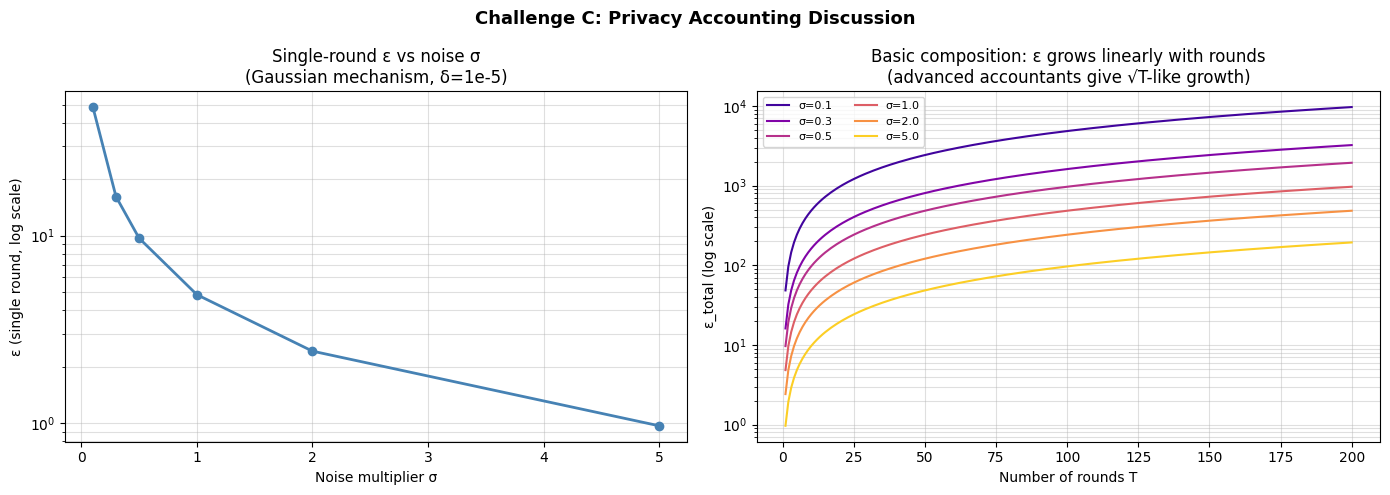


Key takeaway: Basic composition accumulates epsilon linearly (worst-case).
Moments accountant / Rényi DP / PRV give tighter O(sqrt(T)) bounds,
making many-round FL feasible for moderate privacy budgets (e.g., epsilon ≤ 10).


In [57]:
fig_c, axes_c = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: single-round epsilon vs sigma
axes_c[0].plot(sigma_values_c, [single_eps[s] for s in sigma_values_c],
               'o-', color='steelblue', linewidth=2)
axes_c[0].set_yscale('log')
axes_c[0].set_title('Single-round ε vs noise σ\n(Gaussian mechanism, δ=1e-5)')
axes_c[0].set_xlabel('Noise multiplier σ')
axes_c[0].set_ylabel('ε (single round, log scale)')
axes_c[0].grid(True, which='both', alpha=0.4)

# Panel 2: basic composition growth
T_range = np.arange(1, 201)
colors_c = plt.cm.plasma(np.linspace(0.1, 0.9, len(sigma_values_c)))
for s, color in zip(sigma_values_c, colors_c):
    axes_c[1].plot(T_range, T_range * single_eps[s],
                   label=f'σ={s}', color=color, linewidth=1.5)
axes_c[1].set_yscale('log')
axes_c[1].set_title('Basic composition: ε grows linearly with rounds\n'
                     '(advanced accountants give √T-like growth)')
axes_c[1].set_xlabel('Number of rounds T')
axes_c[1].set_ylabel('ε_total (log scale)')
axes_c[1].legend(fontsize=8, ncol=2)
axes_c[1].grid(True, which='both', alpha=0.4)

plt.suptitle('Challenge C: Privacy Accounting Discussion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey takeaway: Basic composition accumulates epsilon linearly (worst-case).")
print("Moments accountant / Rényi DP / PRV give tighter O(sqrt(T)) bounds,")
print("making many-round FL feasible for moderate privacy budgets (e.g., epsilon ≤ 10).")

---
## Challenge D — Stronger Non-IID Regime (α = 0.1)

We repeat the privacy–utility sweep from Part 8 with $\alpha = 0.1$ (more extreme label heterogeneity than the $\alpha = 0.3$ baseline). We then compare:

1. Convergence curves side-by-side (α = 0.3 vs α = 0.1).
2. Final accuracy as a function of noise multiplier for both α values.
3. Per-client accuracy under no DP and strong DP ($\sigma = 1.0$) in the α = 0.1 regime.

The hypothesis is that with stronger heterogeneity, minority clients are harmed even more by added noise.

In [58]:
# Challenge D — Stronger Non-IID Regime (alpha = 0.1)
# ── Fallback definitions (skipped when predecessor cells have already run) ──

if 'SEED' not in dir():
    SEED = 42
if 'K' not in dir():
    K = 10

if 'make_tf_dataset' not in globals():
    def make_tf_dataset(indices, batch_size=32, shuffle=True):
        ds = tf.data.Dataset.from_tensor_slices((X_train[indices], y_train[indices]))
        if shuffle:
            ds = ds.shuffle(max(1, len(indices)), seed=SEED)
        return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

if 'build_model' not in globals():
    def build_model(num_classes=10):
        inp = keras.Input(shape=(8, 8, 1))
        x = layers.Conv2D(16, 3, activation='relu', padding='same')(inp)
        x = layers.MaxPool2D(2)(x)
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
        x = layers.MaxPool2D(2)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(64, activation='relu')(x)
        out = layers.Dense(num_classes, activation='softmax')(x)
        return keras.Model(inp, out)

if 'compute_accuracy' not in globals():
    def compute_accuracy(model, xs, ys):
        probs = model(xs, training=False).numpy()
        preds = np.argmax(probs, axis=1)
        return float(np.mean(preds == ys))

if 'get_weights_copy' not in globals():
    def get_weights_copy(model):
        return [w.numpy().copy() for w in model.weights]

if 'set_weights_from' not in globals():
    def set_weights_from(model, weights):
        for var, w in zip(model.weights, weights):
            var.assign(w)

if 'weighted_average' not in globals():
    def weighted_average(weight_lists, sample_counts):
        total = sum(sample_counts)
        avg = [np.zeros_like(w) for w in weight_lists[0]]
        for wlist, n in zip(weight_lists, sample_counts):
            for i, w in enumerate(wlist):
                avg[i] += (n / total) * w
        return avg

if 'dirichlet_partition' not in globals():
    def dirichlet_partition(y_subset, indices, num_clients, alpha, seed=SEED):
        rng = np.random.default_rng(seed)
        num_classes = len(np.unique(y_subset))
        buckets = [[] for _ in range(num_clients)]
        for c in range(num_classes):
            class_idx = indices[y_subset == c]
            rng.shuffle(class_idx)
            proportions = rng.dirichlet(np.full(num_clients, alpha))
            cuts = (np.cumsum(proportions[:-1]) * len(class_idx)).astype(int)
            splits = np.split(class_idx, cuts)
            for k in range(num_clients):
                buckets[k].extend(splits[k].tolist())
        out = []
        for b in buckets:
            b = np.array(b, dtype=int)
            rng.shuffle(b)
            out.append(b)
        return out

if 'client_update' not in globals():
    def client_update(global_weights, client_idx, local_epochs, lr, cidx):
        local_model = build_model()
        set_weights_from(local_model, global_weights)
        local_model.compile(
            optimizer=keras.optimizers.SGD(lr),
            loss='sparse_categorical_crossentropy')
        ds = make_tf_dataset(cidx[client_idx], batch_size=32, shuffle=True)
        local_model.fit(ds, epochs=local_epochs, verbose=0)
        return get_weights_copy(local_model)

if 'clip_update' not in globals():
    def clip_update(delta, clip_norm):
        global_norm = math.sqrt(sum(np.sum(d * d) for d in delta))
        scale = min(1.0, clip_norm / (global_norm + 1e-12))
        return [d * scale for d in delta]

if 'add_gaussian_noise' not in globals():
    def add_gaussian_noise(delta, clip_norm, noise_multiplier):
        out = []
        for d in delta:
            noise = np.random.normal(0.0, noise_multiplier * clip_norm, size=d.shape)
            out.append(d + noise)
        return out

if 'run_fedavg' not in globals():
    def run_fedavg(rounds=20, local_epochs=1, lr=0.05, participation=1.0,
                   alpha=0.3, seed=SEED, verbose=True):
        rng = np.random.default_rng(seed)
        cidx = dirichlet_partition(y_train, np.arange(len(y_train)), K, alpha, seed=seed)
        global_model = build_model()
        global_weights = get_weights_copy(global_model)
        m = max(1, int(np.ceil(participation * K)))
        history = []
        for t in range(rounds):
            selected = rng.choice(K, size=m, replace=False)
            local_weights, sizes = [], []
            for k in selected:
                wk = client_update(global_weights, k, local_epochs, lr, cidx)
                local_weights.append(wk)
                sizes.append(len(cidx[k]))
            global_weights = weighted_average(local_weights, sizes)
            set_weights_from(global_model, global_weights)
            acc = compute_accuracy(global_model, X_test, y_test)
            history.append(acc)
            if verbose and (t == 0 or (t + 1) % 5 == 0):
                print(f"FedAvg round {t+1:02d}: acc={acc:.3f}")
        return {"history": history, "final_weights": global_weights,
                "client_indices": cidx, "global_model": global_model}

if 'run_noisy_fedavg' not in globals():
    def run_noisy_fedavg(rounds=20, local_epochs=2, lr=0.05, clip_norm=1.0,
                         noise_multiplier=0.5, participation=1.0, alpha=0.3,
                         seed=SEED, verbose=True):
        rng = np.random.default_rng(seed)
        cidx = dirichlet_partition(y_train, np.arange(len(y_train)), K, alpha, seed=seed)
        global_model = build_model()
        global_weights = get_weights_copy(global_model)
        m = max(1, int(np.ceil(participation * K)))
        history = []
        for t in range(rounds):
            selected = rng.choice(K, size=m, replace=False)
            noisy_updates, sizes = [], []
            for k in selected:
                local_model = build_model()
                set_weights_from(local_model, global_weights)
                local_model.compile(
                    optimizer=keras.optimizers.SGD(lr),
                    loss='sparse_categorical_crossentropy')
                ds = make_tf_dataset(cidx[k], batch_size=32, shuffle=True)
                local_model.fit(ds, epochs=local_epochs, verbose=0)
                local_weights = get_weights_copy(local_model)
                delta = [lw - gw for lw, gw in zip(local_weights, global_weights)]
                clipped = clip_update(delta, clip_norm)
                noisy = add_gaussian_noise(clipped, clip_norm, noise_multiplier)
                noisy_updates.append(noisy)
                sizes.append(len(cidx[k]))
            avg_delta = weighted_average(noisy_updates, sizes)
            global_weights = [gw + dw for gw, dw in zip(global_weights, avg_delta)]
            set_weights_from(global_model, global_weights)
            acc = compute_accuracy(global_model, X_test, y_test)
            history.append(acc)
            if verbose and (t == 0 or (t + 1) % 5 == 0):
                print(f"NoisyFedAvg round {t+1:02d}: acc={acc:.3f}")
        return {'history': history, 'final_weights': global_weights,
                'client_indices': cidx, 'global_model': global_model}

sigma_values_d = [0.0, 0.1, 0.3, 0.5, 1.0]
sweep_results_01 = {}

print("Running privacy-utility sweep with alpha=0.1 (stronger heterogeneity)...")
for sigma in sigma_values_d:
    if sigma == 0.0:
        res = run_fedavg(rounds=20, local_epochs=2, alpha=0.1, verbose=False)
    else:
        res = run_noisy_fedavg(
            rounds=20, local_epochs=2, clip_norm=1.0,
            noise_multiplier=sigma, alpha=0.1, verbose=False)
    sweep_results_01[sigma] = res
    print(f"  alpha=0.1 | sigma={sigma:.1f} -> final acc={res['history'][-1]:.3f}")


Running privacy-utility sweep with alpha=0.1 (stronger heterogeneity)...
  alpha=0.1 | sigma=0.0 -> final acc=0.761
  alpha=0.1 | sigma=0.1 -> final acc=0.717
  alpha=0.1 | sigma=0.3 -> final acc=0.158
  alpha=0.1 | sigma=0.5 -> final acc=0.097
  alpha=0.1 | sigma=1.0 -> final acc=0.100


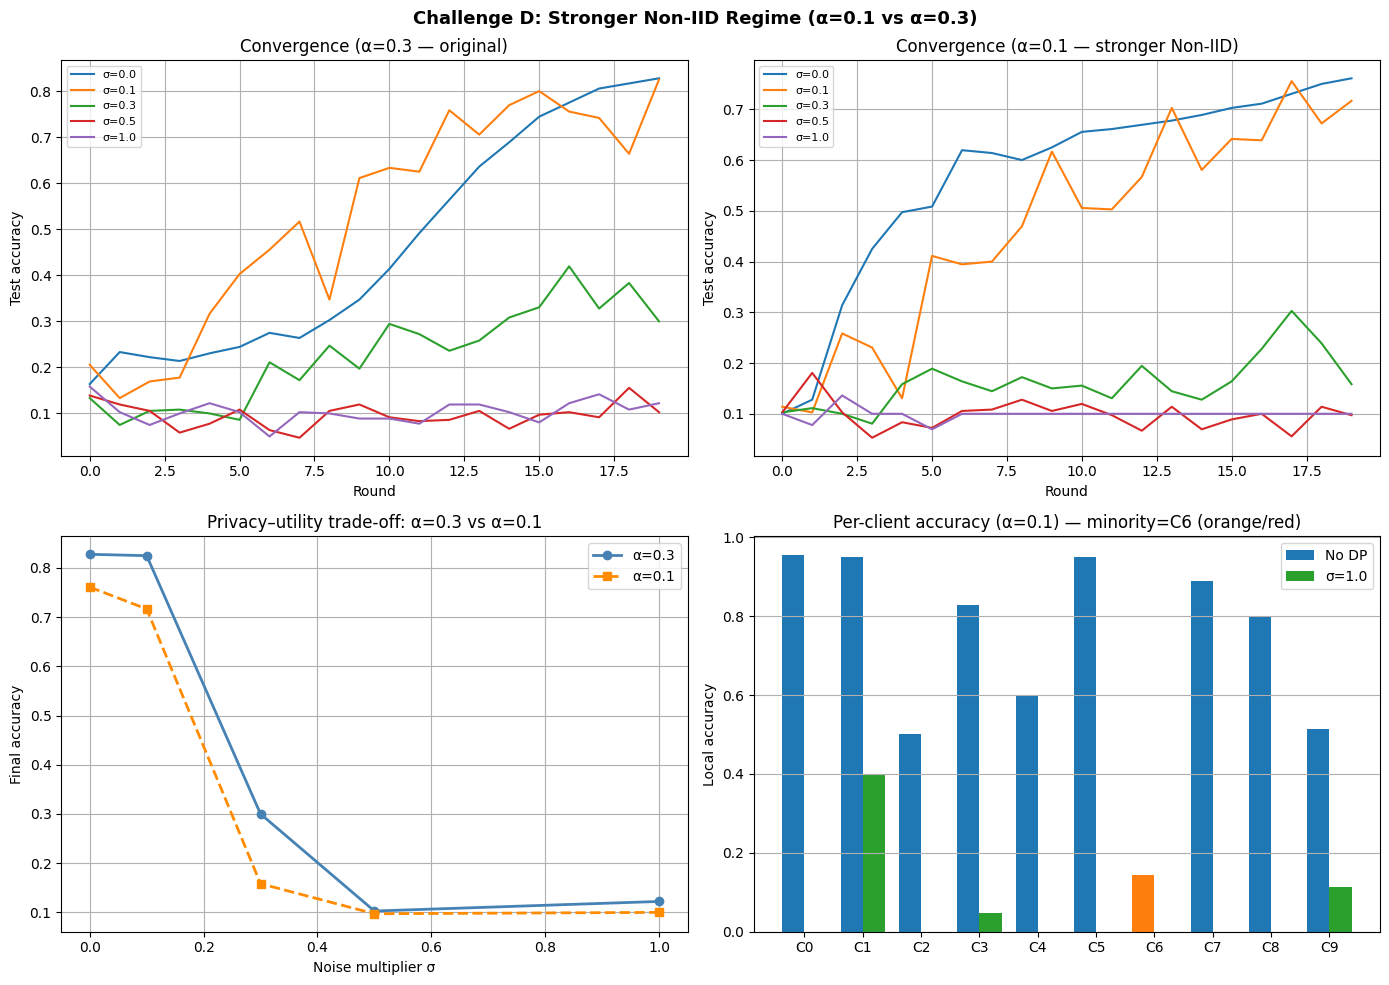


Accuracy drop (σ=0 → σ=1.0):  α=0.3 → 0.706  |  α=0.1 → 0.661
Minority client (α=0.1) C6: 0.143 (no DP) -> 0.000 (σ=1.0), drop = 0.143
Mean drop all clients (α=0.1): 0.713 -> 0.056, drop = 0.657

Conclusion: With α=0.1, the overall accuracy is lower before DP is applied,
and minority clients show a larger absolute accuracy drop under strong DP,
confirming that stronger Non-IID heterogeneity amplifies fairness harm.


In [59]:
# Challenge D — Visualization
# ── Fallback definitions (skipped when predecessor cells have already run) ──

if 'per_client_accuracies' not in globals():
    def per_client_accuracies(weights, local_test_idx):
        model = build_model()
        set_weights_from(model, weights)
        return [compute_accuracy(model, X_train[idx], y_train[idx]) for idx in local_test_idx]

if 'sweep_results' not in globals():
    sigma_values = [0.0, 0.1, 0.3, 0.5, 1.0]
    sweep_results = {}
    print("Building sweep_results (alpha=0.3)...")
    for sigma in sigma_values:
        if sigma == 0.0:
            res = run_fedavg(rounds=20, local_epochs=2, alpha=0.3, verbose=False)
        else:
            res = run_noisy_fedavg(rounds=20, local_epochs=2, clip_norm=1.0,
                                   noise_multiplier=sigma, alpha=0.3, verbose=False)
        sweep_results[sigma] = res
        print(f"  sigma={sigma:.1f} -> final acc={res['history'][-1]:.3f}")

fig_d, axes_d = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: convergence alpha=0.3 (from Part 8 sweep_results)
for sigma, res in sweep_results.items():
    axes_d[0, 0].plot(res['history'], label=f'σ={sigma:.1f}')
axes_d[0, 0].set_title('Convergence (α=0.3 — original)')
axes_d[0, 0].set_xlabel('Round'); axes_d[0, 0].set_ylabel('Test accuracy')
axes_d[0, 0].legend(fontsize=8); axes_d[0, 0].grid(True)

# Panel B: convergence alpha=0.1
for sigma, res in sweep_results_01.items():
    axes_d[0, 1].plot(res['history'], label=f'σ={sigma:.1f}')
axes_d[0, 1].set_title('Convergence (α=0.1 — stronger Non-IID)')
axes_d[0, 1].set_xlabel('Round'); axes_d[0, 1].set_ylabel('Test accuracy')
axes_d[0, 1].legend(fontsize=8); axes_d[0, 1].grid(True)

# Panel C: privacy–utility trade-off comparison
final_03 = [sweep_results[s]['history'][-1]    for s in sigma_values_d]
final_01 = [sweep_results_01[s]['history'][-1] for s in sigma_values_d]
axes_d[1, 0].plot(sigma_values_d, final_03, 'o-', color='steelblue',    label='α=0.3', linewidth=2)
axes_d[1, 0].plot(sigma_values_d, final_01, 's--', color='darkorange', label='α=0.1', linewidth=2)
axes_d[1, 0].set_title('Privacy–utility trade-off: α=0.3 vs α=0.1')
axes_d[1, 0].set_xlabel('Noise multiplier σ'); axes_d[1, 0].set_ylabel('Final accuracy')
axes_d[1, 0].legend(); axes_d[1, 0].grid(True)

# Panel D: per-client accuracy (alpha=0.1), no DP vs sigma=1.0
cidx_01 = sweep_results_01[0.0]['client_indices']
local_test_idx_01 = [idx[:max(5, len(idx)//5)] for idx in cidx_01]
accs_01_s0 = per_client_accuracies(sweep_results_01[0.0]['final_weights'],  local_test_idx_01)
accs_01_s1 = per_client_accuracies(sweep_results_01[1.0]['final_weights'],  local_test_idx_01)
minority_d  = int(np.argmin(accs_01_s0))

x_d = np.arange(K); w_d = 0.38
cols0 = ['tab:orange' if i == minority_d else 'tab:blue'  for i in range(K)]
cols1 = ['tab:red'    if i == minority_d else 'tab:green' for i in range(K)]
axes_d[1, 1].bar(x_d - w_d/2, accs_01_s0, w_d, color=cols0, label='No DP')
axes_d[1, 1].bar(x_d + w_d/2, accs_01_s1, w_d, color=cols1, label='σ=1.0')
axes_d[1, 1].set_xticks(x_d); axes_d[1, 1].set_xticklabels([f'C{i}' for i in range(K)])
axes_d[1, 1].set_ylabel('Local accuracy')
axes_d[1, 1].set_title(f'Per-client accuracy (α=0.1) — minority=C{minority_d} (orange/red)')
axes_d[1, 1].legend(); axes_d[1, 1].grid(True, axis='y')

plt.suptitle('Challenge D: Stronger Non-IID Regime (α=0.1 vs α=0.3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantitative summary
drop_03 = np.array(final_03[0]) - np.array(final_03[-1])
drop_01 = np.array(final_01[0]) - np.array(final_01[-1])
print(f"\nAccuracy drop (σ=0 → σ=1.0):  α=0.3 → {drop_03:.3f}  |  α=0.1 → {drop_01:.3f}")
print(f"Minority client (α=0.1) C{minority_d}: "
      f"{accs_01_s0[minority_d]:.3f} (no DP) -> {accs_01_s1[minority_d]:.3f} (σ=1.0), "
      f"drop = {accs_01_s0[minority_d]-accs_01_s1[minority_d]:.3f}")
print(f"Mean drop all clients (α=0.1): "
      f"{np.mean(accs_01_s0):.3f} -> {np.mean(accs_01_s1):.3f}, "
      f"drop = {np.mean(accs_01_s0)-np.mean(accs_01_s1):.3f}")
print("\nConclusion: With α=0.1, the overall accuracy is lower before DP is applied,")
print("and minority clients show a larger absolute accuracy drop under strong DP,")
print("confirming that stronger Non-IID heterogeneity amplifies fairness harm.")
